
<style>
:root { --ink:#18323f; --teal:#147d7e; --sand:#f3ead7; --rust:#c75532; --mist:#eef5f3; }
.jp-Notebook { max-width: 1180px; margin: auto; }
h1, h2, h3 { color: var(--ink); font-family: Georgia, serif; }
h1 { border-bottom: 4px solid var(--teal); padding-bottom: .25em; }
h2 { border-left: 7px solid var(--rust); padding-left: .55em; margin-top: 1.4em; }
table { font-size: 95%; }
.hero { background: linear-gradient(120deg,#173743,#147d7e); color:white; padding:28px 34px;
        border-radius:16px; margin:8px 0 22px 0; }
.hero h1 { color:white; border:0; margin:0 0 8px 0; }
.hero p { font-size:1.08rem; margin:.25rem 0; }
.callout { background:var(--mist); border-left:6px solid var(--teal); padding:14px 18px;
           border-radius:7px; margin:14px 0; }
.warning { background:#fff1e8; border-left:6px solid var(--rust); padding:14px 18px;
           border-radius:7px; margin:14px 0; }
.metric { display:inline-block; min-width:170px; background:var(--sand); padding:12px 15px;
          border-radius:10px; margin:4px; vertical-align:top; }
.metric b { display:block; font-size:1.35rem; color:var(--teal); }
.small { color:#52646d; font-size:.9rem; }
</style>



<div class="hero">
<h1>Weaknesses, Improvement Priorities, and Literature Map</h1>
<p>An evidence-based research roadmap for the next project phase</p>
<p>Companion notebook to the full V2.6 project evaluation</p>
</div>

> This document separates **verified weaknesses**, **likely mechanisms**, and **proposed experiments**. A strong next phase should reduce uncertainty, not merely add more model complexity.


In [1]:

from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from PIL import Image as PILImage
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / "evaluation").exists():
    ROOT = ROOT.parent

TEST_DIR = ROOT / "evaluation" / "section9_simplex_v2.6_test_policy_comparison"
VAL_DIR = ROOT / "evaluation" / "section9_simplex_v2.6_policy_comparison"
test_summary = json.loads((TEST_DIR / "section9_comparison_summary.json").read_text())
val_summary = json.loads((VAL_DIR / "section9_comparison_summary.json").read_text())

def show_artifact(path, width=15):
    img = PILImage.open(path)
    ratio = img.height / img.width
    plt.figure(figsize=(width, width * ratio))
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def policy_frame(summary):
    rows = []
    for name, m in summary["policies"].items():
        rows.append({
            "Policy": name,
            "Relative wealth": m["mean_relative_wealth_vs_constrained_neutral"],
            "Win rate": m.get("win_rate_vs_constrained_neutral", np.nan),
            "Max drawdown": m["mean_max_drawdown"],
            "Turnover": m["mean_average_turnover"],
            "Constraint-feasible branches": m["constraint_feasible_branch_rate"],
            "Allocation violation": m["mean_allocation_constraint_raw_cost"],
        })
    return pd.DataFrame(rows).set_index("Policy")

test_df = policy_frame(test_summary)
val_df = policy_frame(val_summary)



## 1. Diagnostic Scorecard

### What is healthy

- Hard CAOSD allocation constraints are feasible by construction.
- Relative-wealth test performance is positive for all learned methods.
- RCPO Dirichlet transfers unusually well from validation to test.
- The latest training core uses one lambda update per rollout and a repaired standalone branch gradient path.

### What is unhealthy or unproven

- Drawdown-constrained RCPO is feasible on only **15%-40%** of test branches.
- Soft allocation-penalty RCPO is feasible on **0%** of test branches.
- The evidence is largely **single-seed**, so ranking uncertainty is unknown.
- Dirichlet policies retain high turnover; Gaussian RCPO has low turnover but the highest mean drawdown.
- The environment is synthetic; historical-market transfer has not been established.


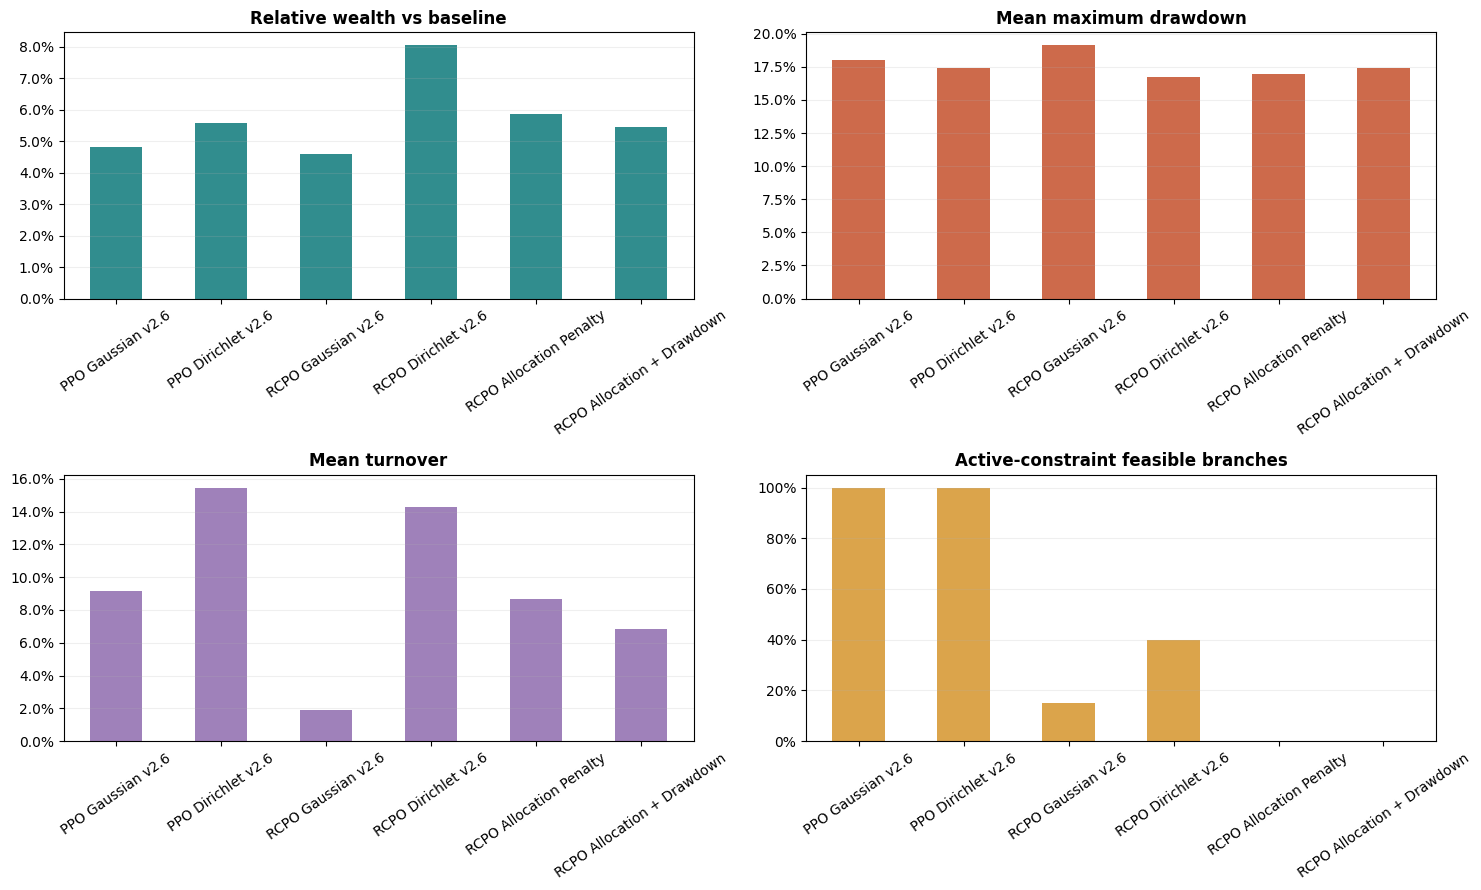

: 

In [ ]:

plot_df = test_df.drop(index="Constrained-neutral baseline").copy()
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
items = [
    ("Relative wealth", "Relative wealth vs baseline", "#147d7e", PercentFormatter(1)),
    ("Max drawdown", "Mean maximum drawdown", "#c75532", PercentFormatter(1)),
    ("Turnover", "Mean turnover", "#9270b1", PercentFormatter(1)),
    ("Constraint-feasible branches", "Active-constraint feasible branches", "#d79832", PercentFormatter(1)),
]
for ax, (col, title, color, formatter) in zip(axes.ravel(), items):
    plot_df[col].plot.bar(ax=ax, color=color, alpha=.88)
    ax.set_title(title, weight="bold"); ax.set_xlabel("")
    ax.yaxis.set_major_formatter(formatter); ax.grid(axis="y", alpha=.2)
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout(); plt.show()


## 2. Weakness 1 - Statistical Evidence Is Too Narrow


### Evidence

The current comparison is strong within one controlled seed and one shared future-market set, but it does not estimate variation across policy initialization, train-market generation, or validation-branch selection.

### Risk to the claim

A +1-3 percentage-point ordering between methods may disappear across seeds. Repeated checkpoint selection on the same ten validation branches may also create selection bias.

### Improvement

1. Run **3 seeds as a pilot**, then **5 seeds for final evidence**.
2. Pre-register a fixed validation set and a disjoint test set.
3. Report median, interquartile range, bootstrap confidence intervals, and paired branch differences.
4. Compare both `checkpoint_best_return.pt` and `checkpoint_best_feasible.pt` without selecting on test data.

### Acceptance criterion

The proposed method should improve paired test relative wealth in at least 4/5 seeds while maintaining the declared feasibility target.


## 3. Weakness 2 - RCPO Does Not Yet Deliver Reliable Drawdown Feasibility

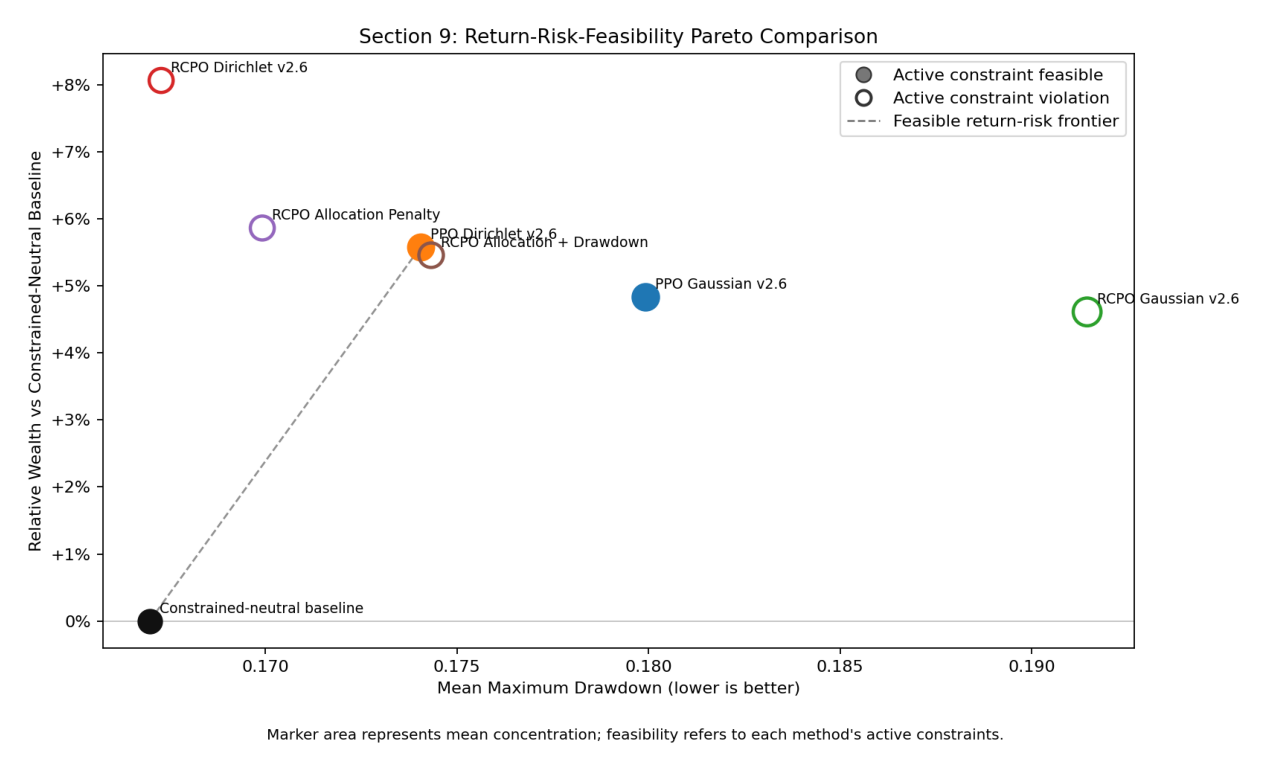

In [3]:
show_artifact(TEST_DIR / 'section9_return_risk_feasibility_pareto.png', 13)


### Evidence

- RCPO Gaussian: 15% feasible test branches.
- RCPO Dirichlet: 40% feasible test branches.
- Their mean drawdowns are close to, or worse than, unconstrained PPO and the baseline.

### Likely causes

1. The squared violation is sparse until the current drawdown crosses an online budget.
2. Average rollout cost can hide a small number of severe branch violations.
3. Best-return checkpoint selection and constraint satisfaction remain competing objectives.
4. A first-order Lagrangian multiplier can oscillate or lag behind non-stationary policy changes.

### Improvement candidates

| Candidate | Expected benefit | Main risk |
|---|---|---|
| CVaR/chance constraint across branches | Targets tail violations rather than average cost | More samples and a quantile estimator |
| Augmented Lagrangian | Stronger correction near persistent violation | Extra penalty coefficient to tune |
| State-wise/current-drawdown barrier | Denser pre-violation signal | May become conservative |
| Lexicographic feasible checkpointing | Honest deployment selection | May sacrifice return |
| Adaptive penalty metric | Learns violation-sensitive pressure | Adds a model and validation burden |

The recent [safe-RL formulation survey](https://www.ijcai.org/proceedings/2024/913) is especially relevant: average cumulative constraints, state-wise constraints, and chance/CVaR constraints answer different safety questions and should not be treated as interchangeable.


## 4. Weakness 3 - Soft Allocation Penalties Do Not Solve Hard Feasibility


### Evidence

Both soft RCPO variants have 0% active allocation-feasible test branches, while all CAOSD policies have zero allocation violation by construction.

### Interpretation

This is not merely a tuning failure. A soft expected-cost objective generally does not guarantee pointwise feasibility for every action. Increasing lambda may reduce violations but can also suppress return learning.

### Project implication

Use the soft penalty as a **comparison baseline**, not as the final hard-constraint solution. The result supports the project's central architecture choice: structural constraints belong in the action map whenever a tractable feasible map exists.

### Focused follow-up

- Plot violation distribution by branch and time, not only the mean.
- Sweep cost scale and alpha to characterize the return-feasibility frontier.
- Compare with action projection as a second hard-feasibility baseline.


## 5. Weakness 4 - Branch Credit Is Still an Approximation


### Current approach

Each simplex branch receives a standalone shadow-portfolio reward, while the final combined portfolio supplies the global cost. This is much better than one identical global advantage for every branch, but it is not the branch's exact marginal contribution.

### Why the approximation matters

- CAOSD masses $z_i$ interact: changing an earlier branch can change downstream composition.
- Transaction costs depend on the full final portfolio path.
- In autoregressive policies, later branches condition on earlier branch actions.

### Phase 2: counterfactual marginal reward

For branch $i$, compare the actual full portfolio with a counterfactual in which only that branch is replaced by its neutral action:

$$r^{\mathrm{CF}}_{i,t}=r_t(a_{1:4})-r_t(a_{-i},a_i^{\mathrm{neutral}}).$$

The policy receives a difference reward tied to its marginal effect, while lambda remains global and is still updated from the actual final portfolio cost.


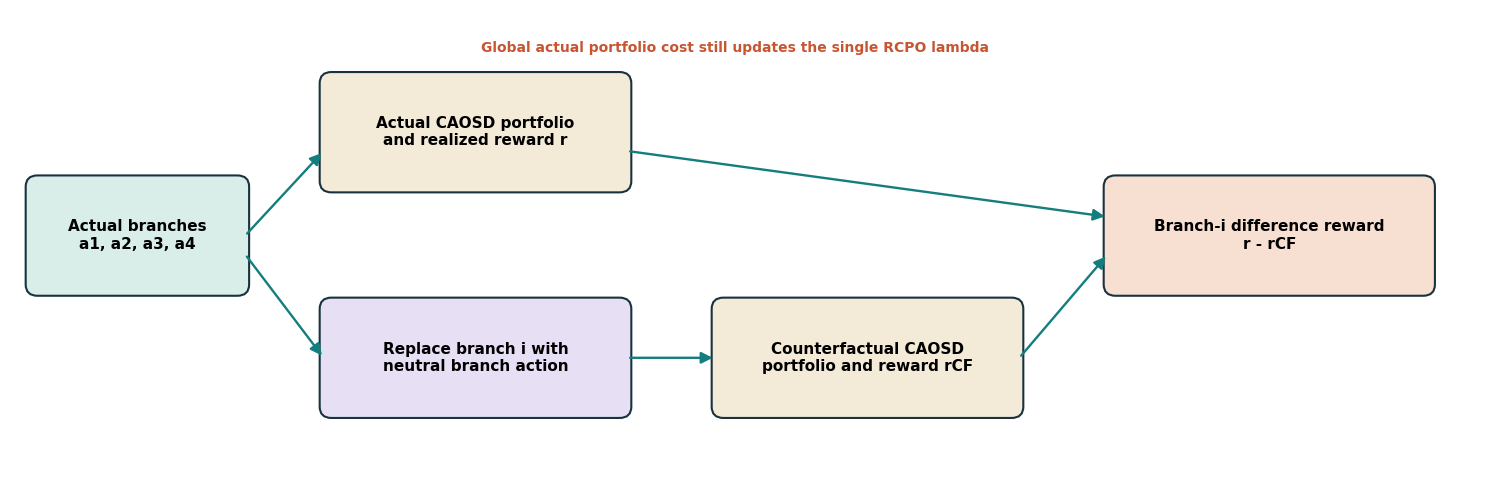

In [4]:

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
fig, ax = plt.subplots(figsize=(15, 5)); ax.set_xlim(0,15); ax.set_ylim(0,5); ax.axis("off")
def box(x,y,w,h,text,color):
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle="round,pad=.04,rounding_size=.12",fc=color,ec="#18323f",lw=1.5))
    ax.text(x+w/2,y+h/2,text,ha="center",va="center",fontsize=11,weight="bold")
box(.2,2,2.2,1.2,"Actual branches\na1, a2, a3, a4","#d9eee9")
box(3.2,3.1,3.1,1.2,"Actual CAOSD portfolio\nand realized reward r","#f3ead7")
box(3.2,.7,3.1,1.2,"Replace branch i with\nneutral branch action","#e7e0f4")
box(7.2,.7,3.1,1.2,"Counterfactual CAOSD\nportfolio and reward rCF","#f3ead7")
box(11.2,2,3.3,1.2,"Branch-i difference reward\nr - rCF","#f7dfd2")
for a,b in [((2.4,2.6),(3.2,3.5)),((2.4,2.4),(3.2,1.3)),((6.3,1.3),(7.2,1.3)),((6.3,3.5),(11.2,2.8)),((10.3,1.3),(11.2,2.4))]:
    ax.add_patch(FancyArrowPatch(a,b,arrowstyle="-|>",mutation_scale=17,lw=1.7,color="#147d7e"))
ax.text(7.4,4.55,"Global actual portfolio cost still updates the single RCPO lambda",ha="center",color="#c75532",weight="bold")
plt.tight_layout(); plt.show()



### Implementation order

1. **Open-loop counterfactual:** hold later sampled branch actions fixed; cheapest first test.
2. **Prefix-coherent counterfactual:** resample downstream branches after replacing an earlier branch.
3. **COMA-like critic baseline:** estimate the marginal value in one critic forward pass.

This direction is conceptually related to [Counterfactual Multi-Agent Policy Gradients](https://arxiv.org/abs/1705.08926), but the project must adapt it to autoregressive CAOSD composition rather than claim a direct algorithmic equivalence.


## 6. Weakness 5 - Policy-Distribution-Specific Instability

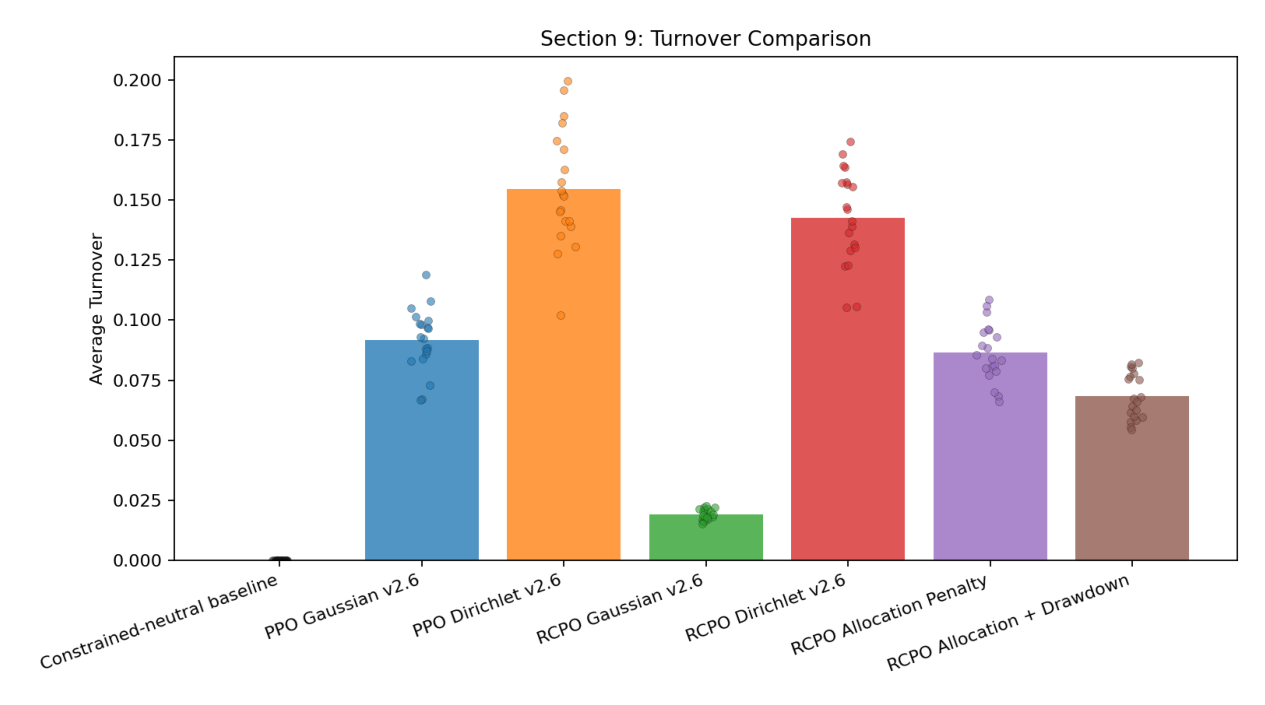

In [5]:
show_artifact(TEST_DIR / 'section9_turnover_comparison.png', 13)


### Dirichlet

- Best current generalization, but turnover remains high (about 14%-15%).
- Concentration bounds reduce collapse but do not directly penalize rapid temporal reallocation.
- A direct simplex distribution is geometrically appropriate, yet entropy and concentration are not interchangeable with Gaussian logit standard deviation.

**Improvements:** turnover-aware observation/regularization, slower concentration updates, separate actor learning rate for concentration heads, and branch-wise entropy diagnostics.

### Gaussian

- Lower turnover, especially for RCPO Gaussian, but weaker return and risk outcomes.
- Logits contain translation-invariant directions: adding a constant to all logits changes likelihood/KL but not branch weights.

**Improvements:** use $K-1$ reference logits per branch, track effective weight-space KL, and tune target KL separately from Dirichlet.


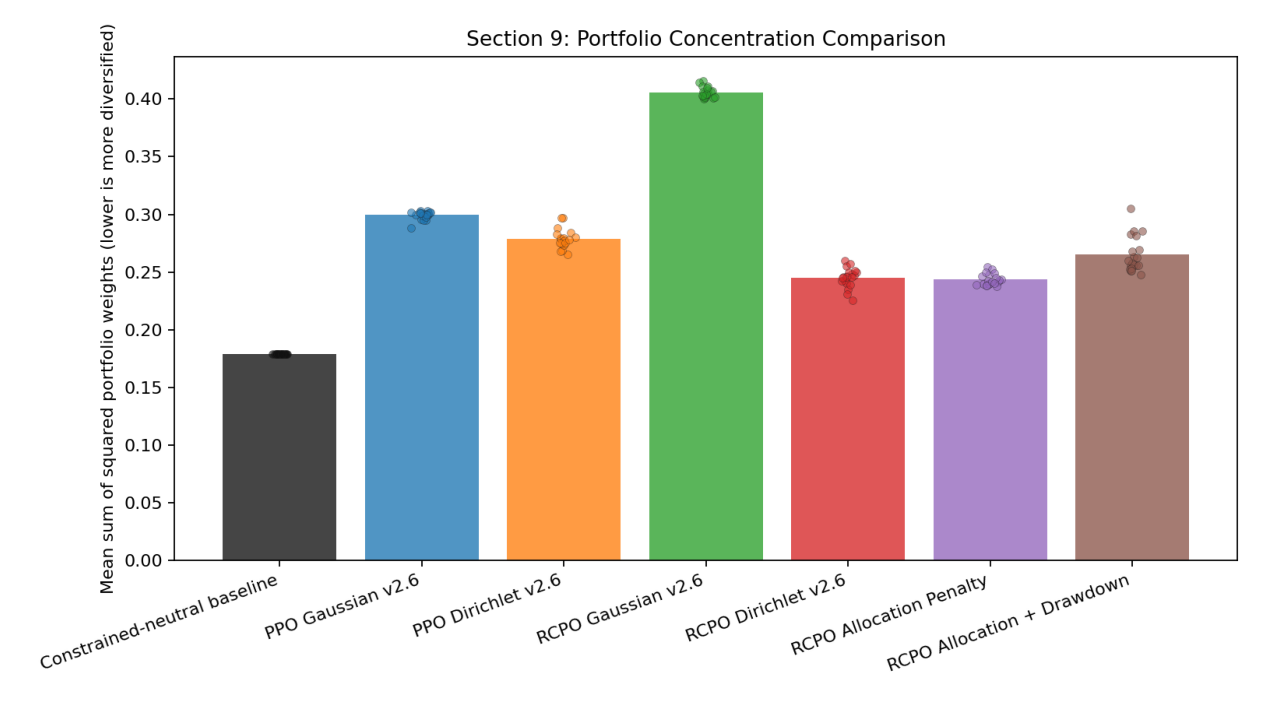

In [6]:
show_artifact(TEST_DIR / 'section9_concentration_comparison.png', 13)

## 7. Weakness 6 - Synthetic-to-Real External Validity


### Evidence gap

The synthetic market intentionally exposes learnable regime, momentum, and correlation structure. This is useful for algorithm diagnosis, but successful synthetic allocation does not imply real-market profitability.

### Required real-market stage

1. Use survivorship-bias-aware historical constituents and realistic corporate-action-adjusted prices.
2. Employ walk-forward training/validation/testing with no overlap or look-ahead.
3. Model slippage, transaction-cost uncertainty, and delayed execution.
4. Compare against constrained-neutral, 1/N, buy-and-hold, minimum variance, risk parity/HRP, and selected RL baselines.
5. Stress-test subperiods by volatility regime and market crash.

The 2025 [risk-adjusted multi-reward portfolio study](https://link.springer.com/article/10.1007/s44196-025-00875-8) is useful as a recent real-market comparison, but this project should retain constraint feasibility as its distinguishing focus rather than simply combine reward functions.


## 8. Weakness 7 - Reward Robustness Is Not Yet a Natural-Market Experiment


The earlier noisy-reward experiments manually injected Gaussian noise. They were useful engineering tests, but they should not become the main research claim.

### Better robustness formulation

- Treat close-to-execution price mismatch, uncertain fees, stale state windows, missing values, and delayed fills as the source of imperfect feedback.
- Keep a latent clean accounting return only for controlled diagnostics; train the agent on the realistically observed signal.
- Evaluate DRC/GDRC only after the simplex + RCPO core is stable.

The [DRC/GDRC framework](https://arxiv.org/abs/2401.05710) motivates this direction because it learns under perturbed rewards, but a finance-specific perturbation model and strict clean test accounting are required.


## 9. Prioritized Improvement Roadmap


| Priority | Experiment | Decision enabled | Stop/go rule |
|---:|---|---|---|
| 1 | Five-seed V2.6 reproduction with best-return and best-feasible checkpoints | Are current rankings reliable? | Continue only if paired advantage is consistent |
| 2 | Open-loop counterfactual branch reward ablation | Is branch credit the learning bottleneck? | Keep if return improves without worse KL/turnover |
| 3 | CVaR or chance-constrained branch-level drawdown objective | Can feasibility improve beyond mean-cost RCPO? | Target >=80% feasible test branches |
| 4 | Augmented-Lagrangian / adaptive penalty comparison | Is lambda lag or cost sparsity limiting RCPO? | Better feasibility at comparable return |
| 5 | Historical walk-forward experiment | Does the method survive market shift? | Positive paired excess with realistic costs |
| 6 | Natural noisy state/reward + DRC/GDRC | Does reward correction add robustness? | Improvement over uncorrected policies across noise sources |

<div class="warning"><b>Do not start with a larger network.</b> The current bottlenecks are evidence quality, credit assignment, and constraint formulation. More capacity would make attribution harder before these issues are resolved.</div>


## 10. Proposed Experiment Matrix

In [7]:

matrix = pd.DataFrame([
    ["V2.6 reproduction", "Gaussian / Dirichlet", "PPO / RCPO", "Current", "3 pilot -> 5 final", "Return, feasibility, KL, turnover"],
    ["Counterfactual credit", "Dirichlet", "PPO / RCPO", "Open-loop neutral replacement", "3", "Paired improvement vs standalone"],
    ["Risk formulation", "Best policy family", "RCPO", "Mean / CVaR / augmented Lagrangian", "3", "Feasible-branch rate and tail DD"],
    ["Historical transfer", "Best two", "PPO / RCPO", "Walk-forward", ">=3 windows", "Net return, MDD, costs, feasibility"],
    ["Feedback robustness", "Best historical", "PPO / RCPO + optional GDRC", "Execution/state imperfections", "3", "Clean-accounting test return"],
], columns=["Study", "Policy", "Algorithm", "Ablation", "Replications", "Primary evidence"])
display(matrix)


,Study,Policy,Algorithm,Ablation,Replications,Primary evidence
0,V2.6 reproduction,Gaussian / Dirichlet,PPO / RCPO,Current,3 pilot -> 5 final,"Return, feasibility, KL, turnover"
1,Counterfactual credit,Dirichlet,PPO / RCPO,Open-loop neutral replacement,3,Paired improvement vs standalone
2,Risk formulation,Best policy family,RCPO,Mean / CVaR / augmented Lagrangian,3,Feasible-branch rate and tail DD
3,Historical transfer,Best two,PPO / RCPO,Walk-forward,>=3 windows,"Net return, MDD, costs, feasibility"
4,Feedback robustness,Best historical,PPO / RCPO + optional GDRC,Execution/state imperfections,3,Clean-accounting test return


## 11. Literature-to-Action Map


| Literature | Direct lesson for this project | Concrete next use |
|---|---|---|
| [CAOSD / Simplex Decomposition](https://arxiv.org/abs/2404.10683) | Encode linear allocation feasibility in policy structure | Retain as the hard-constraint core |
| [RCPO](https://openreview.net/forum?id=SkfrvsA9FX) | Adaptive multiplier separates reward and cost | Keep as baseline constrained learner |
| [Safe-RL constraint survey, IJCAI 2024](https://www.ijcai.org/proceedings/2024/913) | Expected, state-wise, worst-case, and chance constraints are different formulations | Reframe drawdown target before tuning lambda again |
| [Exterior Penalty Policy Optimization, IJCAI 2024](https://www.ijcai.org/proceedings/2024/443) | Adaptive penalties can react to violation severity | Compare with current linear lambda update |
| [Safe and Balanced, TPAMI 2025](https://doi.org/10.1109/TPAMI.2025.3528944) | Conflicting reward and constraint gradients may need explicit coordination | Diagnose actor gradient alignment |
| [Augmented Lagrangian portfolio RL, AAAI 2025](https://ojs.aaai.org/index.php/AAAI/article/view/35252) | Portfolio-specific augmented multipliers may stabilize risk control | Implement as focused RCPO alternative |
| [COMA counterfactual credit](https://arxiv.org/abs/1705.08926) | Difference baselines isolate component contribution | Adapt to CAOSD branches in Phase 2 |
| [DRC/GDRC perturbed rewards](https://arxiv.org/abs/2401.05710) | Distributional critics can correct imperfect reward feedback | Use only under natural execution/state noise |
| [Risk-adjusted multi-reward portfolio RL, 2025](https://link.springer.com/article/10.1007/s44196-025-00875-8) | Recent historical-market risk/return evaluation reference | Benchmark evaluation protocol, not constraint guarantee |


## 12. Recommended Next Research Claim


<div class="callout"><b>Recommended narrow claim:</b> A hybrid policy that encodes linear allocation constraints through Simplex Decomposition and learns path-dependent risk preferences through a constrained optimizer can outperform either soft penalties or unconstrained simplex policies, provided branch credit and risk formulation are handled explicitly.</div>

To support that claim, the next evidence should prioritize:

1. multi-seed statistical reliability;
2. explicit hard-feasibility versus soft-penalty comparison;
3. a counterfactual branch-credit ablation;
4. a risk formulation that targets branch-level tail feasibility;
5. historical walk-forward validation.

Until those steps are complete, the correct wording is **promising synthetic evidence**, not a final real-market result.
